## Load functions

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
import pickle
import pandas as pd
import os

In [2]:
def determine_sample_color(x):
    ''' 
    Find to which macrostate the last sample belongs (Kp, P+L,P,A+D,A) and choose a color accordingly.
    '''

    x = x[:,-1] #the last transfer

    ### Kp, Km, A, P, D, L is the correct order   
    if x[2]>0.05: #Alcaligenes present
        if x[4]<0.01: #Delftia absent
            cluster = 1
        else:
            cluster = 2
    elif x[3]>0.05: #Pseudomonas present
        if x[5,]<0.01: #lachnoclostridium absent
            cluster = 3
        else:
            cluster = 4
    else: #both alcaligenes and pseudomonas absent
        cluster = 0

    return cluster

In [4]:
dataset_name = 'Estrella_full'


''' Load the model, aka the eigenvalues and eigenvectors, inferred from the dataset '''
with open('../../out/{}/eigvects.{}.dat'.format(dataset_name,dataset_name),'rb') as f:
    eigvects = pickle.load(f)
    f.close()

with open('../../out/{}/eigvals.{}.dat'.format(dataset_name,dataset_name),'rb') as f:
    eigvals = pickle.load(f)
    f.close()

with open('../../out/{}/low_variance_eigenmodes.{}.dat'.format(dataset_name,dataset_name),'rb') as f:
    lowvar_eigvects = pickle.load(f)
    f.close()

with open('../../out/{}/low_variance_eigvals.{}.dat'.format(dataset_name,dataset_name),'rb') as f:
    lowvar_eigvals = pickle.load(f)
    f.close()

In [5]:
df = pd.read_csv('Estrela_2021_16S_data_table_ALL_processed.csv')

In [6]:
np.unique(df[( df['Transfer']==2)]['Inoc_size'])

array(['higher', 'lower'], dtype=object)

### Check the replicates with sequencing done every transfer.

For regardless of migration treatment, by running "print(len(np.unique(list(df[( df['Transfer']==2)&( df['Treatment']=={Treatment Type})]['Rep_num']))))"

This yields:

No_migration -> 24 replicates 

Global_migration -> 8 replicates 

Parent_migration -> 0 replicates

In [7]:

print(len(np.unique(list(df[( df['Transfer']==3)&( df['Treatment']=='No_migration')&( df['Inoc_size']=='higher')]['Rep_num']))))


4


In [8]:
''' Get the replicate IDs '''
which_transfer = 16 #should give the same number of samples, unless one chooses 18, in which case one gets the complete dataset.
No_migration_replicate_IDs = np.unique(list(df[( df['Transfer']==which_transfer)&( df['Treatment']=='No_migration')&( df['Inoc_size']=='lower')]['Rep_num']))
Global_migration_replicate_IDs = np.unique(list(df[( df['Transfer']==which_transfer)&( df['Treatment']=='Global_migration')&( df['Inoc_size']=='lower')]['Rep_num']))
print(len(No_migration_replicate_IDs),len(Global_migration_replicate_IDs))
N_replicates = len(No_migration_replicate_IDs)+len(Global_migration_replicate_IDs)

''' 
From here on, samples will be first sorted by migration type (No,Global), and then by ascending replicate number.
'''

20 8


' \nFrom here on, samples will be first sorted by migration type (No,Global), and then by ascending replicate number.\n'

### Build the dataset matrix

At each time, with ESV abundances. Keep only the same taxa as were used to infer the low- and high-variance modes, ignoring the rest.

In [11]:
'''
Open the dataset 
'''
data_dir = '../../datasets/'
with open(os.path.join(data_dir,'true_datasets/full_dataset.Estrella_full.dat'),'rb') as f:
    full_dataset = pickle.load(f)
    M,N =np.shape(full_dataset)
    f.close()

full_dataset_reduced = full_dataset[:,:14]

with open(os.path.join(data_dir,'taxonomic_tags/family_tags.Estrella_full.dat'),'rb') as f:
    family_tags = pickle.load(f)
    f.close()

with open('OTU_tags.Estrella_full.dat','rb') as f:
    OTU_tags = pickle.load(f)
    f.close()

print(np.shape(full_dataset),
      np.shape(family_tags),
      np.shape(OTU_tags))

### Sanity check. For each OTU in OTU_tags, search its taxonomy in the dataframe and check that it matches the annotation used in the data analysis, for all transfers
has_error = 0
which_transfer = 2
for which_transfer in range(1,19):
    for i,OTU in enumerate(OTU_tags):
        df_OTU = df[( df['Transfer']==which_transfer)&( df['Treatment']=='Global_migration')&( df['Inoc_size']=='lower')&(df['OTU']==OTU)]
        true_taxonomy = family_tags[i][0]
        true_tag = family_tags[i][2:] #ignore the "x:" indicating phylogeny
        if true_taxonomy=='g':
            tags = df_OTU['Genus']
        elif true_taxonomy=='f':
            tags = df_OTU['Genus'] #for some reason they are named 'f.' even though the genus is used.
        elif true_taxonomy=='o': 
            tags = df_OTU['Family'] #for some reason they are named 'o' even though the family is used.
            
        for tag in tags:
            if tag!=true_tag:
                print('Error!')
                print(true_taxonomy,tag,true_tag)
                has_error = 1
if has_error==0:   
    print('No errors')

(276, 48) (48,) (48,)
No errors


In [12]:
total_number_ESVs = len(np.unique(list(df[(df['Transfer']==1)&( df['Inoc_size']=='lower')]['OTU']))) #at the end of transfer 1
candidate_OTU_list = np.unique(list(df[(df['Transfer']==1)&( df['Inoc_size']=='lower')]['OTU'])) #of all OTUs present in the dataset
print('Total Number of ESVs',total_number_ESVs)

Total Number of ESVs 188


## You can skip straight to data analysis

### No need to run this. Go straight to data analysis.

In [14]:
''' 
Build the dataset matrix, at each time, with ESV abundances.
Keep only the 14 most commons ESVs that are present in the final transfer and used for the inference process. Ignore the rest.
'''



dynamics_full_dataset = np.zeros((N_replicates,total_number_ESVs,18)) 

for migration in ['No_migration','Global_migration']:
    print('Migration type:',migration)
    replicate_list = No_migration_replicate_IDs if migration=='No_migration' else Global_migration_replicate_IDs
    for i,replicate in enumerate(replicate_list):
        if migration!='No_migration':
            i += len(No_migration_replicate_IDs)
        print('Sample/Replicate',i,replicate)
        for j,OTU in enumerate(candidate_OTU_list):
            for k,transfer in enumerate(range(1,19)):
                abundance = df[
                (df['Transfer']==transfer)&
                (df['Treatment']==migration)&
                (df['Rep_num']==replicate)&
                (df['OTU']==OTU)&
                (df['Inoc_size']=='lower') #very important, else it sums abundances from both lower and higher inoculum sizes
                ]['Abundance']
                if abundance.empty == False:
                    abundance = float(abundance.iloc[0])
                    dynamics_full_dataset[i,j,k] = abundance

Migration type: No_migration
Sample/Replicate 0 2
Sample/Replicate 1 3
Sample/Replicate 2 5
Sample/Replicate 3 6
Sample/Replicate 4 14
Sample/Replicate 5 15
Sample/Replicate 6 18
Sample/Replicate 7 20
Sample/Replicate 8 26
Sample/Replicate 9 31
Sample/Replicate 10 32
Sample/Replicate 11 36
Sample/Replicate 12 44
Sample/Replicate 13 45
Sample/Replicate 14 49
Sample/Replicate 15 54
Sample/Replicate 16 63
Sample/Replicate 17 75
Sample/Replicate 18 77
Sample/Replicate 19 85
Migration type: Global_migration
Sample/Replicate 20 21
Sample/Replicate 21 25
Sample/Replicate 22 31
Sample/Replicate 23 42
Sample/Replicate 24 49
Sample/Replicate 25 52
Sample/Replicate 26 63
Sample/Replicate 27 84


In [15]:
np.sum(dynamics_full_dataset.sum(axis=1)>1.00001)

0

In [16]:
with open('dynamics_full_dataset.dat','wb') as f:
    pickle.dump(dynamics_full_dataset,f)
    f.close()

## Data analysis

In [17]:
with open('dynamics_full_dataset.dat','rb') as f:
    dynamics_full_dataset = pickle.load(f)
    f.close()

In [18]:
''' 
Keep only the taxa present in the final transfer (in the dataset that we analyzed such that they appear in high-low-var modes).

Ojo: it is possible that some taxa present in the final transfers of the analyzed dataset are not present in this dynamical 
dataset, since it only includes 20+8 out of 92+92 replicates and rare taxa could be absent since the beginning in the 28 replicates considered here.
'''

reduced_dynamics_full_dataset = np.zeros((N_replicates,N,18))

for i,true_OTU in enumerate(OTU_tags):
    if true_OTU in candidate_OTU_list:
        j = np.where(candidate_OTU_list==true_OTU)[0][0]
        reduced_dynamics_full_dataset[:,i,:] = dynamics_full_dataset[:,j,:]

[0.9977754  0.99638962 1.00000003 1.         0.99762065 0.99743298
 1.         0.99480755 0.9986489  1.         0.99999995 1.
 0.99491356 0.99846385 1.         0.99363904 0.99799257 1.
 0.99829301 0.83194086 0.99809162 0.99674102 0.9987126  1.
 0.99921695 0.99760896 0.99970343 0.99824477]


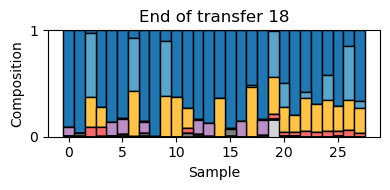

In [19]:
color_scheme = np.array([(0,122,159), #Kp
          (90,165,202), #Km
          (255,196,69), #Alcaligenes
          (187,143,198), #pseudomonas
          (248,106,106), #delftia
          (185,218,219), #lachnocrostidium
    ])/255


fig,ax = plt.subplots(figsize=(4,2))
''' Select transfer from (1,5,10,18) to plot the panels in the SI Figure '''
which_transfer = 18
last_transfer = reduced_dynamics_full_dataset[:,:,which_transfer-1]
print(np.sum(last_transfer,axis=1))
ax.fill_between(x=np.arange(np.shape(reduced_dynamics_full_dataset)[0]+1)-0.5,
                y1=0,y2=1,
                color='lightgray')
ax.bar(range(np.shape(reduced_dynamics_full_dataset)[0]),
       last_transfer[:,0],width=1,edgecolor='k')
for s in range(1,14):
    if s<6: color = color_scheme[s]
    else: color = 'gray'
    ax.bar(range(np.shape(reduced_dynamics_full_dataset)[0]),
           last_transfer[:,s],color=color,
           bottom = np.cumsum(last_transfer,axis=1)[:,s-1],
           width=1,edgecolor='k')
ax.set_ylim(top=1)
ax.set_yticks([0,1]); ax.set_yticklabels([1,0])
ax.yaxis.set_inverted(True)
ax.set_xlabel('Sample')
ax.set_ylabel('Composition')
ax.set_title('End of transfer {}'.format(which_transfer))
plt.tight_layout()
plt.savefig('Estrela_dynamics.transfer{}.svg'.format(which_transfer),transparent=True)

# Score the datasets with the dynamics

Use the eigenmodes learned from the dataset of final assemblies to calculate the likelihoods of the datasets across transfers (aka time).

In [20]:
N_kept = 14 #as in the manuscript

In [21]:
reduced_dynamics_full_dataset_filtered = reduced_dynamics_full_dataset[:,:N_kept,:] #keep the 14 most abundant taxa as in the true dataset

In [22]:
empirical_correlation_matrix = np.zeros((N_kept,N_kept))
ignore_relative_abundance_mode = True
if ignore_relative_abundance_mode:
    for mode in range(1,np.shape(eigvects)[1]):
        empirical_correlation_matrix += eigvals[mode] * np.outer(eigvects[:,mode],eigvects[:,mode])
    
    np.fill_diagonal(empirical_correlation_matrix,1)
else:
    for mode in range(np.shape(eigvects)[1]):
        empirical_correlation_matrix += eigvals[mode] * np.outer(eigvects[:,mode],eigvects[:,mode])

In [23]:
true_means = np.mean(full_dataset[:,:N_kept],axis=0)
true_stds = np.std(full_dataset[:,:N_kept],axis=0)

In [24]:
''' Calculate z-scores of the abundances of the dynamical dataset, 
with respect to the mean and std in the original T18 dataset,
since the analyses were done with the correlation matrix at the last transfer.

This implies that, for each replicate (timeseries), the z-scores should initially be very strong and negative,
as species abundances are well below what they'll be in the last transfer, and slowly grow towards 
0 +- 1std

'''
z_scores = (reduced_dynamics_full_dataset_filtered-true_means[None,:,None])/true_stds[None,:,None]

In [25]:
N

48

In [26]:
def Hopfield_weight(eigenval):
    if eigenval>1:
        a = 1-1/eigenval
    else:
        a = 1/eigenval-1
    return a


if ignore_relative_abundance_mode:
    J = np.eye(N_kept)
    for mode in range(1,np.shape(eigvects)[1]):
        eigenval = eigvals[mode]
        a = Hopfield_weight(eigenval)
        J += a * np.outer(eigvects[:,mode],eigvects[:,mode])
    
else:
    J = np.eye(N_kept)
    for mode in range(np.shape(eigvects)[1]):
        eigenval = eigvals[mode]
        a = Hopfield_weight(eigenval)
        J += a * np.outer(eigvects[:,mode],eigvects[:,mode])

det = 1/np.linalg.det(J) #det(C) = 1/det(J)


def log_pdf(x,J,det):
    '''
    x = (N_samples,N_species)
    '''
    numerator = -1/2*x@(J@x.T)
    numerator = np.diagonal(numerator)
    denominator = 1/2*np.log((2*np.pi)**N_kept*det)
    return numerator-denominator #subtraction because its logpdf.





In [27]:
sample_colors = np.array([(0,122,159), #Kp color; Kp dominates
          (255,196,69), #Alcaligenes color; delftia absent
          (248,106,106), #delftia present
          (187,143,198), #pseudomonas color, Lach absent
          (185,218,219), #lachnocrostidium present
    ])/255

labels = ['Kp','A','A+D','P','P+L']

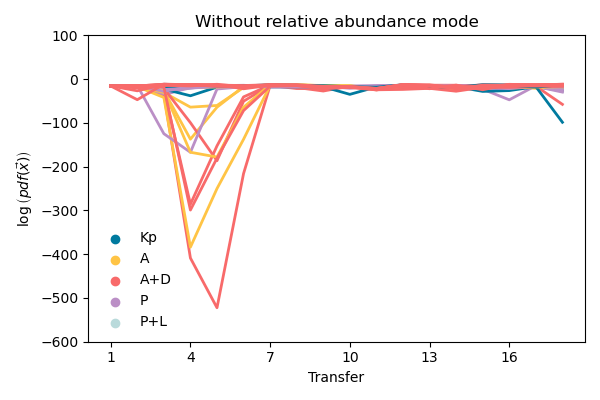

In [28]:
%matplotlib widget
plt.close('all')
fig,ax = plt.subplots(figsize=(6,4))
for sample in range(N_replicates):
    color = determine_sample_color(z_scores[sample,:,:])
    # logpdfs = multivariate_normal.logpdf(z_scores[sample,:,:].T,
    #                                 cov = empirical_correlation_matrix,
    #                                   )

    logpdfs = log_pdf(z_scores[sample,:,:].T,
                        J,det)


    #Sanity check: Both methods are exactly equivalent.
    ax.plot(np.arange(18),
                logpdfs,
           color=sample_colors[color],# if sample != 19 else 'tab:orange',
            alpha=1,linewidth=2)

    if logpdfs[-1]<-500: print('Lowprob sample:',sample)

# ax.set_yscale('log')
for c,color in enumerate(sample_colors):
    ax.scatter(None,None,color=color,label=labels[c])
ax.legend(loc='upper left' if ignore_relative_abundance_mode == False else 'best',frameon=False)
ax.set_xticks(np.arange(0,18,3))
ax.set_xticklabels(np.arange(0,18,3)+1)
ax.set_xlabel('Transfer')
ax.set_ylabel(r'$\log{\left(pdf\left(\vec{x}\right)\right)}$')
if ignore_relative_abundance_mode:
    title = 'Without relative abundance mode'; ymin = -600
else:
    title = 'Including relative abundance mode'; ymin = -1500
ax.set_title(title)
ax.set_ylim(bottom = ymin,top=100)
plt.tight_layout()
plt.savefig('logpdf.remove_relativeabu.{}.svg'.format(ignore_relative_abundance_mode),transparent=True)

In [29]:
'''
You can check something empirically that is very puzzling.

If you calculate the logprobs from scipy pdf by taking the empirical correlation matrix, WITHOUT the mode of LARGEST variance (eigenmode -1 in python indexing),
but ensuring the diagonal of the matrix is 1,

and

you calculate the logprobs explicitly using the determinant (prod(eigvals)) and the precision matrix, WITHOUT the mode of SMALLEST variance (eigenmode 0)


you get very similar results.
'''

'\nYou can check something empirically that is very puzzling.\n\nIf you calculate the logprobs from scipy pdf by taking the empirical correlation matrix, WITHOUT the mode of LARGEST variance (eigenmode -1 in python indexing),\nbut ensuring the diagonal of the matrix is 1,\n\nand\n\nyou calculate the logprobs explicitly using the determinant (prod(eigvals)) and the precision matrix, WITHOUT the mode of SMALLEST variance (eigenmode 0)\n\n\nyou get very similar results.\n'

### Check how much each individual low-variance mode is satisfied across transfers, for each replicate.

Calculate $\vec{e}_\alpha^T \cdot \vec{z(t)}$, for each sample.

In [30]:
print('Pseudomonas',reduced_dynamics_full_dataset_filtered[:,3,-1])
print('Pseudomonas',z_scores[:,3,-1]*eigvects[3,2])
print('Lachnosclostridium',z_scores[:,5,-1]*eigvects[5,2])

Pseudomonas [8.40641710e-02 5.64122000e-04 9.34000000e-05 0.00000000e+00
 1.38160765e-01 1.42713241e-01 0.00000000e+00 1.02624787e-01
 5.12486000e-04 0.00000000e+00 0.00000000e+00 0.00000000e+00
 1.29222944e-01 1.19381149e-01 1.34704000e-04 6.98000000e-05
 1.46893506e-01 0.00000000e+00 1.43092589e-01 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
Pseudomonas [ 0.31338969 -0.38176142 -0.38568025 -0.38645782  0.76375239  0.80165247
 -0.38645782  0.46790975 -0.3821913  -0.38645782 -0.38645782 -0.38645782
  0.68934361  0.60740912 -0.38533639 -0.38587673  0.83645384 -0.38645782
  0.8048106  -0.38645782 -0.38645782 -0.38645782 -0.38645782 -0.38645782
 -0.38645782 -0.38645782 -0.38645782 -0.38645782]
Lachnosclostridium [0.37610969 0.37610969 0.37610969 0.37610969 0.37610969 0.37610969
 0.37610969 0.37610969 0.37610969 0.37610969 0.37610969 0.37610969
 0.37610969 0.37610969 0.37610969 0.37610969 0.376109

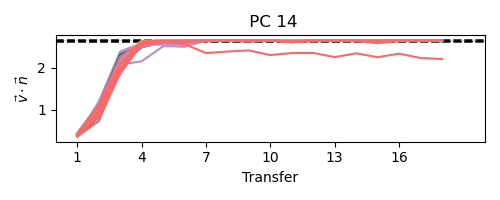

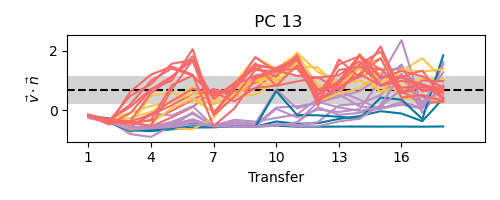

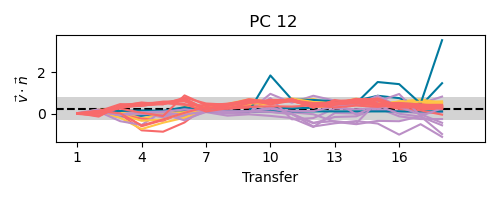

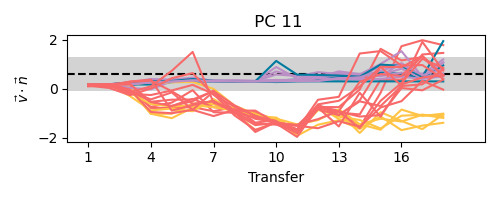

In [31]:
plot_inset=False
use_zscores = False #Set to true to draw in z-scored abundances.
for i in range(np.shape(lowvar_eigvects)[1]):
    mode = lowvar_eigvects[:,i]
    if i==0: mode = -mode #to match sign criterion
    if i==2: mode = -mode #to match signs in the other figure and match the producer-consumer interpretation
    std = np.sqrt(lowvar_eigvals[i]) 
    fig,ax = plt.subplots(figsize=(5,2))
    
    
    for j in range(N_replicates):
        nonrescaled_sample = reduced_dynamics_full_dataset_filtered[j,:,:]
        color = determine_sample_color(nonrescaled_sample)
        if use_zscores:
            ax.fill_between(np.arange(-1,20),
                            -std,+std,
                            facecolor='lightgray',
                           )
            ax.axhline(y=0,xmin=0,xmax=19,color='k',linestyle='--')
            sample = z_scores[j,:,:]
            dotprod = np.dot(mode,sample,) #dot product is taken along sample dim=0, which is the species dimension (ok), 
                                            #and returns a vector of length=18, the number of transfers.
            ylabel = r'$\vec{e} \cdot \vec{z}$'
        else:
            mode_rescaled = mode/true_stds

            mean_mode = np.mean(mode_rescaled@full_dataset_reduced.T)
            ax.fill_between(np.arange(-1,20),
                            mean_mode-std,mean_mode+std,
                            facecolor='lightgray',zorder=0
                           )
            ax.axhline(y=mean_mode,xmin=0,xmax=19,color='k',linestyle='--',zorder=0)
            sample = reduced_dynamics_full_dataset_filtered[j,:,:]
            dotprod = np.dot(mode_rescaled,sample,)
            ylabel = r'$\vec{v} \cdot \vec{n}$'

            

        ax.plot(dotprod,c=sample_colors[color],
                alpha=1,linewidth=1.5)

    ax.set_xlim(-1,19)
    ax.set_xticks(np.arange(0,18,3))
    ax.set_xticklabels(np.arange(0,18,3)+1)
    ax.set_xlabel('Transfer')
    ax.set_ylabel(ylabel)
    ax.set_title(' PC {}'.format(N_kept-i))
    if N_kept-i==14 and plot_inset:
        fig.set_figheight(2)
        fig.set_figwidth(3)
        ax.set_xlim(15.5,17)
        ax.set_xticks([16,17])
        ax.set_xticklabels([17,18])
        ax.set_ylim(-std*2,+std*2)
        plt.tight_layout()
        plt.savefig('PC{}.inset.svg'.format(N_kept-i),transparent=True)
        asdasdas
    plt.tight_layout()
    if use_zscores:
        plt.savefig('PC{}_zscores.svg'.format(N_kept-i),transparent=True)
    else:
        plt.savefig('PC{}.svg'.format(N_kept-i),transparent=True)

    

    
        
        

### Plot trajectories along the production-consumption plane

(3, 18)
(5, 18)


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_41576\964477371.py:45: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(dotprod1[-1],dotprod2[-1],
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_41576\964477371.py:84: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  cbar = plt.colorbar(sm,shrink=1.0,pad = 0.1,location='right',ticks=[1,6,12,18])


(12, 18)
(8, 18)
(3, 18)
(5, 18)
(12, 18)
(8, 18)
(3, 18)
(5, 18)
(12, 18)
(8, 18)


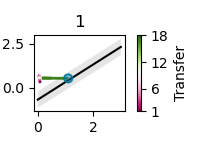

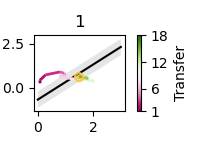

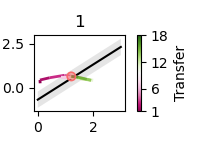

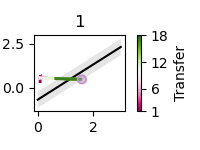

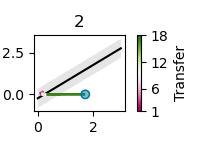

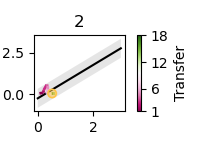

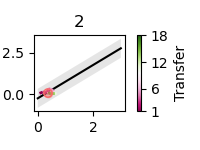

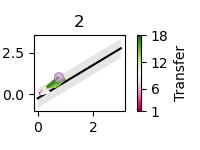

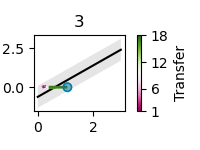

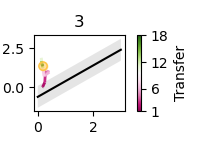

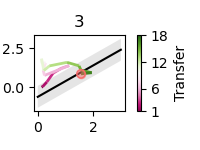

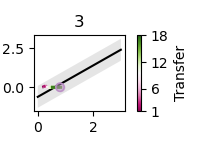

In [35]:
''' Plot trajectories along positive-negative projections, for the average trajectory, separated by enterotype '''
enterotypes = np.array([determine_sample_color(reduced_dynamics_full_dataset_filtered[i,:,:]) for i in range(28)])
import matplotlib as mpl
time_vect = np.arange(18)/17 #time from 0 to 1
plt.close('all')
for i in range(np.shape(lowvar_eigvects)[1]):
    if i==0: continue #skip relative abundance mode
    mode = lowvar_eigvects[:,i]/true_stds
    if i==2: mode = -mode #flip vector signs to match producer-consumer signs in all figures.
    pos = mode>0
    neg = mode<0
    std = np.sqrt(lowvar_eigvals[i]/2) #recall factor 2 in the spread wrt the central line

    
    
    for enterotype in range(4): #you can skip the last enterotype because lachnoclostridium is never present in the end in the samples with timeseries.
        fig,ax = plt.subplots(figsize=(2,1.5))
        xvect = np.linspace(0,3,100)
        mean_pos = np.mean(mode[pos]@full_dataset_reduced[:,pos].T)  
        mean_neg = -np.mean(mode[neg]@full_dataset_reduced[:,neg].T)
        ax.plot(xvect,mean_neg+(xvect-mean_pos),'k-')
        spread = (std*np.sqrt(2))
        ax.fill_between(xvect,
                        mean_neg+(xvect-mean_pos)-spread,
                        mean_neg+(xvect-mean_pos)+spread,
                        facecolor='gray',zorder=0,
                        alpha=0.2)

        ##################################### PLOT AVERAGE TRAJECTORY FOR EACH ENTEROTYPE ####################################
        current_enterotype = np.arange(28)[enterotypes==enterotype]
        sample = reduced_dynamics_full_dataset_filtered[current_enterotype,:,:]
        color = enterotype
        cmap = plt.get_cmap('PiYG')
        color_vect = [cmap(i) for i in time_vect]
        dotprods1 = np.dot(mode[pos],sample[:,pos,:],) #dot product is taken along second-to-last dimension of smaple, which is the species dimension (ok), 
                                        #and returns a vector of length=18, the number of transfers.
        print(dotprods1.shape)
        dotprod1 = np.mean(dotprods1,axis=0)
        dotprods2 = -np.dot(mode[neg],sample[:,neg,:])
        dotprod2 = np.mean(dotprods2,axis=0)
        points = np.array([dotprod1, dotprod2]).T.reshape(-1, 1, 2)
        segments = np.concatenate([points[:-1], points[1:]], axis=1)
        lc = LineCollection(segments, colors=color_vect[:-1], linewidth=2,alpha=1)
        ax.add_collection(lc)
        ax.scatter(dotprod1[-1],dotprod2[-1],
                c = sample_colors[color],zorder=10,
                alpha = 0.5,linewidth=1)
        ax.scatter(dotprod1[-1],dotprod2[-1],
                facecolor='none',
                edgecolor = sample_colors[color],zorder=11,
                alpha = 1,linewidth=1)
        norm = mpl.colors.Normalize(vmin=1,
                            vmax = 18)
        sm = mpl.cm.ScalarMappable(cmap=cmap,norm=norm)
        sm.set_array([])
        cbar = plt.colorbar(sm,shrink=1.0,pad = 0.1,location='right',ticks=[1,6,12,18])
        cbar.set_label('Transfer',)
        ax.set_title(i)
        plt.tight_layout()
        plt.savefig('mode{}_enterotype{}_posneg_projection.svg'.format(i,enterotype),format='svg',transparent=True)


In [81]:
enterotypes = [determine_sample_color(reduced_dynamics_full_dataset_filtered[i,:,:]) for i in range(28)]
print(enterotypes)

[3, 0, 2, 2, 3, 3, 1, 3, 0, 1, 1, 2, 3, 3, 1, 0, 3, 1, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2]


In [83]:
reduced_dynamics_full_dataset_filtered.shape

(28, 14, 18)